# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/afreensumai64/ML-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Can observable page-level search, traffic, engagement, freshness, and performance signals be used to rank pages for review so that limited content resources can be focused on the most relevant opportunities first?

### Decision Supported

This analysis supports a content team's decision about which pages should be reviewed first for potential refresh, visibility review, or monitoring.

The output is a decision-support ranking, not an automatic instruction to change content. The analysis does not claim that refreshing a page will cause improved search performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset and Windows

This project uses the FlyRank internship warehouse, release `v20260703`.

The main tables used are:

- `fact_content_daily_performance` — daily page-level search and performance observations.
- `dim_content` — content-level metadata, including content creation dates.

### Analysis Windows

- **February 2026:** decision-time feature window.
- **March 2026:** observed outcome window used for evaluation.
- **June 2026:** sealed/final warehouse month and is not used for model development.

### Features

The model uses information available by the February decision point:

- GSC impressions
- GSC clicks
- Content age in days

### Exclusions

The analysis excludes future-window information, label-derived variables, product-generated priority or health fields, private client information, credentials, raw exports, and any client names, domains, URLs, or private search queries.

The March outcome is treated as an observed outcome proxy rather than a direct measure of successful content refresh.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Method Choice

This project uses Logistic Regression because the goal is to rank pages for review while keeping the model interpretable.

The model combines observable February decision-time signals rather than relying on a single manually chosen threshold.

### Features

The model uses:

- GSC impressions
- GSC clicks
- Content age in days

These features are available at the February 2026 decision point.

### Outcome Definition

The observed March outcome proxy, `went_dark`, is defined as:

- `1` when observed March GSC clicks are zero
- `0` when observed March GSC clicks are greater than zero

This is an observed outcome proxy and is not treated as ground truth for whether a content refresh would succeed.

### Baseline

The Week-4 transparent baseline assigns a score from 0–4 using:

- content age
- February search impressions

Higher scores indicate stronger directional signals for review.

### Validation Design

The data is divided into an 80/20 train/test split using grouped splitting by `client_hash_id`.

The baseline and Logistic Regression model are evaluated on the same held-out test population.

The primary ranking metric is Precision@50. Average Precision is also reported.

### Leakage Check

Only February decision-time information is used as model features.

March information is used only to construct the observed outcome.

Future-window performance, label-derived fields, and product-generated priority or health fields are excluded from the model.

In [1]:
# Capstone methodology: load data and reproduce the modeling setup

import os
import pandas as pd
import numpy as np
import duckdb

from google.colab import userdata

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

# Hugging Face authentication
HF_TOKEN = userdata.get("HF_TOKEN")

# DuckDB connection
con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf_secret "
    f"(TYPE HUGGINGFACE, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

FEB = f"{REL}/fact_content_daily_performance/month=2026-02/*.parquet"
MAR = f"{REL}/fact_content_daily_performance/month=2026-03/*.parquet"
DIM_CONTENT = f"{REL}/dim_content.parquet"

print("DuckDB connection: READY")
print("February source: READY")
print("March source: READY")
print("Content dimension: READY")

DuckDB connection: READY
February source: READY
March source: READY
Content dimension: READY


In [2]:
# Build the capstone modeling dataset

FEB_FEATURES = con.sql(f"""
WITH feb AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS gsc_impressions,
        SUM(gsc_clicks) AS gsc_clicks
    FROM read_parquet('{FEB}')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
),

content AS (
    SELECT
        client_hash_id,
        content_hash_id,
        content_created_date
    FROM read_parquet('{DIM_CONTENT}')
)

SELECT
    f.client_hash_id,
    f.content_hash_id,
    f.gsc_impressions,
    f.gsc_clicks,

    DATE_DIFF(
        'day',
        c.content_created_date,
        DATE '2026-02-28'
    ) AS content_age_days

FROM feb f
JOIN content c
    ON f.client_hash_id = c.client_hash_id
   AND f.content_hash_id = c.content_hash_id

WHERE c.content_created_date IS NOT NULL
""").df()


MAR_OUTCOME = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,

    CASE
        WHEN SUM(gsc_clicks) = 0 THEN 1
        ELSE 0
    END AS went_dark

FROM read_parquet('{MAR}')
WHERE gsc_data_available IS TRUE
GROUP BY client_hash_id, content_hash_id
""").df()


model_df = FEB_FEATURES.merge(
    MAR_OUTCOME,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("February feature rows:", len(FEB_FEATURES))
print("March outcome rows:", len(MAR_OUTCOME))
print("Final modeling rows:", len(model_df))
print("Outcome rate:", round(model_df["went_dark"].mean(), 4))

display(model_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

February feature rows: 153559
March outcome rows: 176738
Final modeling rows: 134238
Outcome rate: 0.5684


,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,content_age_days,went_dark
0,client_e547b89c05043229,content_1eea820697c3b95a,299.0,0.0,226,1
1,client_e547b89c05043229,content_9abd8b303f805847,733.0,6.0,226,0
2,client_e547b89c05043229,content_5f58c55cbfee172a,514.0,0.0,226,1
3,client_e547b89c05043229,content_6fe390ba3af1e456,2931.0,3.0,226,0
4,client_e547b89c05043229,content_3ad5d2160242b9ca,970.0,2.0,226,0


In [3]:
# Train the Logistic Regression model and build the Week-4 baseline

feature_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "content_age_days"
]

model_df = model_df.dropna(
    subset=feature_cols + ["went_dark", "client_hash_id"]
).copy()

X = model_df[feature_cols]
y = model_df["went_dark"]
groups = model_df["client_hash_id"]


# 80/20 grouped train-test split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


# Logistic Regression
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

model_scores = model.predict_proba(X_test)[:, 1]


# Precision@K
def precision_at_k(y_true, scores, k=50):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    order = np.argsort(scores)[::-1][:k]

    return y_true[order].mean()


# Model metrics
model_precision_50 = precision_at_k(
    y_test,
    model_scores,
    50
)

model_ap = average_precision_score(
    y_test,
    model_scores
)


# Create test-set results
test_results = model_df.iloc[test_idx].copy()

test_results["model_score"] = model_scores


# Week-4 baseline score
test_results["baseline_score"] = (
    np.select(
        [
            (test_results["content_age_days"] >= 365) &
            (test_results["gsc_impressions"] < 100),

            (test_results["content_age_days"] >= 365) &
            (test_results["gsc_impressions"] < 1000),

            (test_results["content_age_days"].between(180, 364)) &
            (test_results["gsc_impressions"] < 100),

            (test_results["content_age_days"].between(180, 364)) &
            (test_results["gsc_impressions"] < 1000),

            test_results["gsc_impressions"] < 100,

            test_results["gsc_impressions"] < 1000
        ],
        [
            4, 3, 3, 2, 2, 1
        ],
        default=0
    )
)


# Baseline metrics
baseline_precision_50 = precision_at_k(
    test_results["went_dark"],
    test_results["baseline_score"],
    50
)

baseline_ap = average_precision_score(
    test_results["went_dark"],
    test_results["baseline_score"]
)


# Comparison table
comparison = pd.DataFrame({
    "Method": [
        "Week-4 Baseline",
        "Logistic Regression"
    ],
    "Precision@50": [
        baseline_precision_50,
        model_precision_50
    ],
    "Average Precision": [
        baseline_ap,
        model_ap
    ]
})

display(comparison)

,Method,Precision@50,Average Precision
0,Week-4 Baseline,0.84,0.820167
1,Logistic Regression,1.00,0.897893


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model vs Baseline

The Logistic Regression model and the Week-4 transparent baseline are evaluated on the same held-out test set.

The primary metric is Precision@50, which measures the proportion of observed positive outcomes among the 50 highest-ranked pages.

Average Precision is also reported to evaluate ranking quality across the full test set.

The comparison is descriptive: it shows how the two ranking approaches performed on this observed evaluation set. It does not establish that the model will produce the same results on future data.

In [4]:
# Display the final model vs baseline results

results_table = comparison.copy()

results_table["Precision@50"] = results_table["Precision@50"].round(4)
results_table["Average Precision"] = results_table["Average Precision"].round(4)

display(results_table)

,Method,Precision@50,Average Precision
0,Week-4 Baseline,0.84,0.8202
1,Logistic Regression,1.00,0.8979


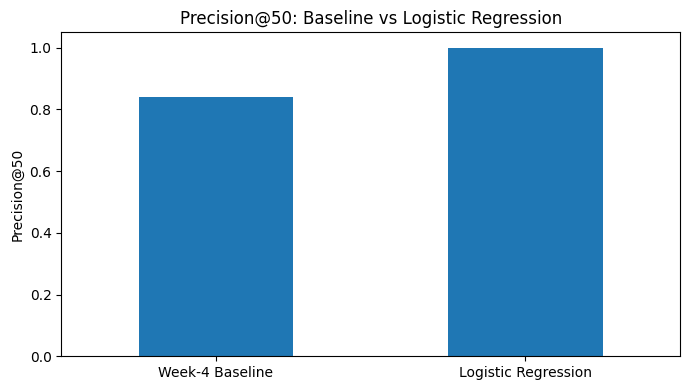

In [6]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)

plot_df = comparison.set_index("Method")["Precision@50"]

ax = plot_df.plot(kind="bar", figsize=(7, 4))

ax.set_title("Precision@50: Baseline vs Logistic Regression")
ax.set_ylabel("Precision@50")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "work/outputs/capstone_precision_at_50.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 5. Limitations

*What this work cannot claim.*

### Limitations and Honest Framing

This analysis has several important limitations.

First, `went_dark` is an observed outcome proxy based on March GSC clicks being zero. It does not represent whether a content refresh would actually succeed.

Second, the analysis is observational. The results show measured relationships in the available data and do not establish that changing or refreshing a page will cause better search performance.

Third, low impressions or clicks can have legitimate explanations, including low search demand, seasonal behavior, or intentional targeting. A high model score should therefore be treated as a review signal rather than an automatic action.

Fourth, the model uses only three verified page-level features: GSC impressions, GSC clicks, and content age. Additional signals could change the ranking if they are available without introducing leakage.

Finally, the reported results come from one held-out evaluation split. Performance may differ on other clients, time periods, or future data.

The output should therefore be used as decision support for prioritizing human review, not as an automated content decision system.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked Content Review Queue

The model score is used to rank pages by their observed likelihood of the `went_dark` outcome.

The ranking is intended to help a content team decide which pages to inspect first. It does not automatically prescribe a content change.

The action labels below provide a simple review playbook:

- `review_refresh` — inspect the page for freshness, relevance, and content-quality opportunities.
- `review_visibility` — inspect search visibility and query/page alignment.
- `monitor` — retain the page for monitoring rather than prioritizing immediate review.

The recommendations below are generated from the held-out evaluation population so that they remain separate from the model's training data.

In [7]:
# Build the ranked recommendation queue from the held-out test set

recommendations = test_results.copy()

recommendations["rank"] = (
    recommendations["model_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

recommendations["reason_code"] = np.select(
    [
        (recommendations["content_age_days"] >= 365) &
        (recommendations["gsc_impressions"] < 100),

        (recommendations["content_age_days"] >= 365) &
        (recommendations["gsc_impressions"] < 1000),

        (recommendations["content_age_days"].between(180, 364)) &
        (recommendations["gsc_impressions"] < 100),

        (recommendations["content_age_days"].between(180, 364)) &
        (recommendations["gsc_impressions"] < 1000),

        recommendations["gsc_impressions"] < 100,

        recommendations["gsc_impressions"] < 1000
    ],
    [
        "stale_low_visibility",
        "stale_moderate_visibility",
        "aging_low_visibility",
        "aging_moderate_visibility",
        "low_visibility",
        "moderate_visibility"
    ],
    default="monitor"
)

recommendations["action"] = np.select(
    [
        recommendations["reason_code"].isin([
            "stale_low_visibility",
            "stale_moderate_visibility",
            "aging_low_visibility",
            "aging_moderate_visibility"
        ]),
        recommendations["reason_code"].isin([
            "low_visibility",
            "moderate_visibility"
        ])
    ],
    [
        "review_refresh",
        "review_visibility"
    ],
    default="monitor"
)

recommendations = recommendations.sort_values(
    ["model_score", "baseline_score"],
    ascending=[False, False]
)

top_recommendations = recommendations[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "baseline_score",
        "content_age_days",
        "gsc_impressions",
        "gsc_clicks",
        "reason_code",
        "action"
    ]
].head(20)

display(top_recommendations)

,rank,client_hash_id,content_hash_id,model_score,baseline_score,content_age_days,gsc_impressions,gsc_clicks,reason_code,action
10658,1,client_9958f0a7ae1df715,content_16eb1251863ca04b,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
10787,2,client_9958f0a7ae1df715,content_7705d2e20abdb738,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
22016,3,client_9958f0a7ae1df715,content_29caac8293c2b5fe,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
35884,4,client_9958f0a7ae1df715,content_44f52de82f2b3888,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
35895,5,client_9958f0a7ae1df715,content_be62c296de95948e,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
41820,6,client_9958f0a7ae1df715,content_6322a23d23f77a1f,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
46638,7,client_9958f0a7ae1df715,content_f14be505493f6c2b,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
47302,8,client_9958f0a7ae1df715,content_ad96b6464e66019f,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
47303,9,client_9958f0a7ae1df715,content_3161f3d25837193d,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
48354,10,client_9958f0a7ae1df715,content_42678c4ab22f4294,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh


In [8]:
# Public-safe recommendation table for the research paper

paper_recommendations = top_recommendations.copy()

paper_recommendations["recommendation_id"] = [
    f"R{i:02d}" for i in range(1, len(paper_recommendations) + 1)
]

paper_recommendations = paper_recommendations[
    [
        "recommendation_id",
        "model_score",
        "baseline_score",
        "content_age_days",
        "gsc_impressions",
        "gsc_clicks",
        "reason_code",
        "action"
    ]
]

display(paper_recommendations)

,recommendation_id,model_score,baseline_score,content_age_days,gsc_impressions,gsc_clicks,reason_code,action
10658,R01,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
10787,R02,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
22016,R03,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
35884,R04,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
35895,R05,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
41820,R06,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
46638,R07,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
47302,R08,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
47303,R09,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
48354,R10,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Public-Facing Artifacts

The paper embeds compact, reproducible artifacts that summarize the evaluation and recommendation output.

The artifacts are designed to be public-safe and contain no client names, domains, URLs, private queries, or credentials.

The main artifacts are:

1. Precision@50 comparison between the Week-4 baseline and Logistic Regression.
2. Average Precision comparison between the Week-4 baseline and Logistic Regression.
3. A public-safe ranked recommendation table using recommendation IDs instead of client or content identifiers.

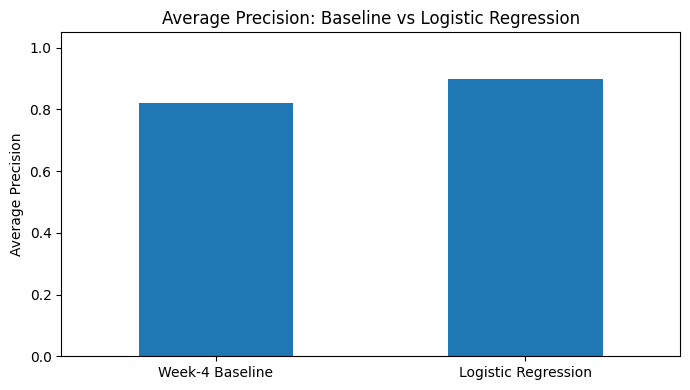

In [9]:
# Average Precision comparison chart

import os
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)

plot_df = comparison.set_index("Method")["Average Precision"]

ax = plot_df.plot(kind="bar", figsize=(7, 4))

ax.set_title("Average Precision: Baseline vs Logistic Regression")
ax.set_ylabel("Average Precision")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "work/outputs/capstone_average_precision.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [10]:
# Display the public-safe recommendation artifact

display(paper_recommendations)

,recommendation_id,model_score,baseline_score,content_age_days,gsc_impressions,gsc_clicks,reason_code,action
10658,R01,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
10787,R02,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
22016,R03,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
35884,R04,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
35895,R05,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
41820,R06,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
46638,R07,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
47302,R08,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
47303,R09,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh
48354,R10,0.823752,4,416,1.0,0.0,stale_low_visibility,review_refresh


## ML-12 — Communication Outputs

### 5-Minute Demo Outline

1. Introduce the content-review prioritization problem.
2. Show the February decision-time features and March observed outcome proxy.
3. Explain the transparent Week-4 baseline.
4. Show the Logistic Regression ranking approach.
5. Compare Precision@50 and Average Precision.
6. Show the ranked recommendation queue and explain how a content team could use it.
7. Close with limitations and the decision-support framing.

### Social-Post Cut

Built a content opportunity ranking workflow using the FlyRank internship dataset.

I compared a transparent rule-based baseline with an interpretable Logistic Regression model using page-level search signals and content age. The evaluation used a held-out grouped test set and Precision@50 as the primary ranking metric.

The result is a reproducible decision-support workflow that turns observable page signals into a ranked review queue, while avoiding causal claims about search performance.

### Employer-Facing Summary

I built an end-to-end content opportunity scoring workflow using real search and content-performance data. The project combines SQL-based feature construction, leakage-aware validation, interpretable machine learning, ranking evaluation, and a public-safe recommendation output. The final artifact demonstrates how ML can support practical prioritization decisions while clearly separating observed evidence from causal claims.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
